In [1]:
!pip install pandas scikit-learn matplotlib openpyxl


In [2]:
import pandas as pd

# Load Excel files
train_df = pd.read_excel("train_data.csv.xlsx")
test_df = pd.read_excel("test_data.csv.xlsx")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (42920, 7)
Test shape: (8845, 7)


,duration,protocol,scheme,status,amount,amount2,fraud
0,0,tcp,ftp_data,SF,491,0,1
1,0,udp,other,SF,146,0,1
2,0,tcp,private,S0,0,0,1
3,0,tcp,http,SF,232,8153,1
4,0,tcp,http,SF,199,420,1


In [3]:
# Separate features and labels
X_train = train_df.drop("fraud", axis=1)
y_train = train_df["fraud"]

X_test = test_df.drop("fraud", axis=1)
y_test = test_df["fraud"]

# One-hot encode categorical features
X_train = pd.get_dummies(X_train, columns=["protocol","scheme","status"])
X_test = pd.get_dummies(X_test, columns=["protocol","scheme","status"])

# Align train and test columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

X_train.head()


,duration,amount,amount2,protocol_icmp,protocol_tcp,protocol_udp,scheme_IRC,scheme_X11,scheme_Z39_50,scheme_aol,...,status_REJ,status_RSTO,status_RSTOS0,status_RSTR,status_S0,status_S1,status_S2,status_S3,status_SF,status_SH
0,0,491,0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,0,146,0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,0,232,8153,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,199,420,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Train with balanced class weights
model = RandomForestClassifier(n_estimators=100,
                               class_weight="balanced",
                               random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("\nROC-AUC:", roc_auc_score(y_test, y_pred))


Confusion Matrix:
 [[   0   56]
 [   1 8788]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        56
           1       0.99      1.00      1.00      8789

    accuracy                           0.99      8845
   macro avg       0.50      0.50      0.50      8845
weighted avg       0.99      0.99      0.99      8845


ROC-AUC: 0.499943110706565


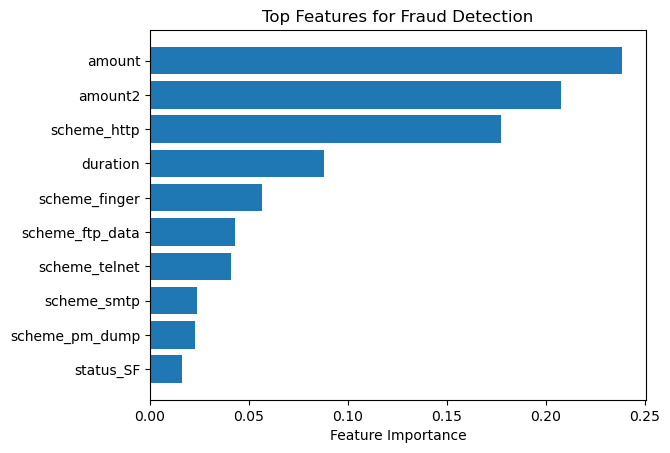

In [7]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
indices = importances.argsort()[-10:]  # top 10 features

plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top Features for Fraud Detection")
plt.show()


In [8]:
# Add predictions to test dataset
test_df["predicted_fraud"] = y_pred
test_df.head()


,duration,protocol,scheme,status,amount,extra_amount,fraud,predicted_fraud
0,0,tcp,private,REJ,0,0,1,1
1,2,tcp,ftp_data,SF,12983,0,1,1
2,0,icmp,eco_i,SF,20,0,1,1
3,1,tcp,telnet,RSTO,0,15,1,1
4,0,tcp,http,SF,267,14515,1,1


In [10]:
# Check dataset shape and column names
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.columns)


Train shape: (42920, 7)
Test shape: (8845, 8)
Index(['duration', 'protocol', 'scheme', 'status', 'amount', 'amount2',
       'fraud'],
      dtype='object')


In [11]:
train_df.info()
train_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42920 entries, 0 to 42919
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   duration  42920 non-null  int64 
 1   protocol  42920 non-null  object
 2   scheme    42920 non-null  object
 3   status    42920 non-null  object
 4   amount    42920 non-null  int64 
 5   amount2   42920 non-null  int64 
 6   fraud     42920 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 2.3+ MB


,duration,amount,amount2,fraud
count,42920.000000,4.292000e+04,4.292000e+04,42920.000000
mean,827.830848,1.177643e+05,5.741407e+04,0.999441
std,4402.249605,1.005498e+07,6.889146e+06,0.023641
min,0.000000,0.000000e+00,0.000000e+00,0.000000
25%,0.000000,2.110000e+02,3.320000e+02,1.000000
50%,0.000000,2.630000e+02,1.021500e+03,1.000000
75%,0.000000,3.380000e+02,3.348500e+03,1.000000
max,42908.000000,1.379964e+09,1.309937e+09,1.000000


In [12]:
train_df.isnull().sum()
test_df.isnull().sum()


duration           0
protocol           0
scheme             0
status             0
amount             0
extra_amount       0
fraud              0
predicted_fraud    0
dtype: int64

<Axes: title={'center': 'Fraud vs Normal in Train Set'}, xlabel='fraud'>

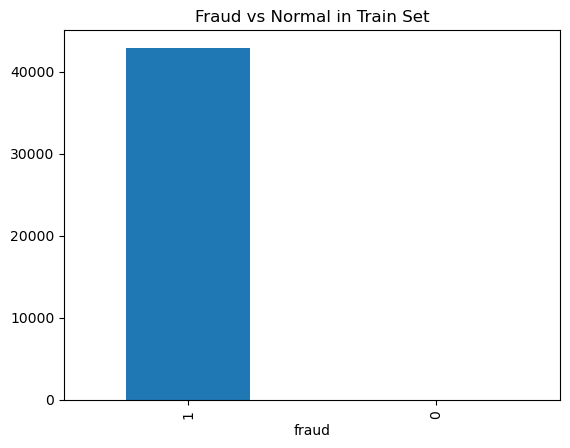

In [13]:
train_df['fraud'].value_counts().plot(kind='bar', title='Fraud vs Normal in Train Set')


<Axes: xlabel='protocol', ylabel='count'>

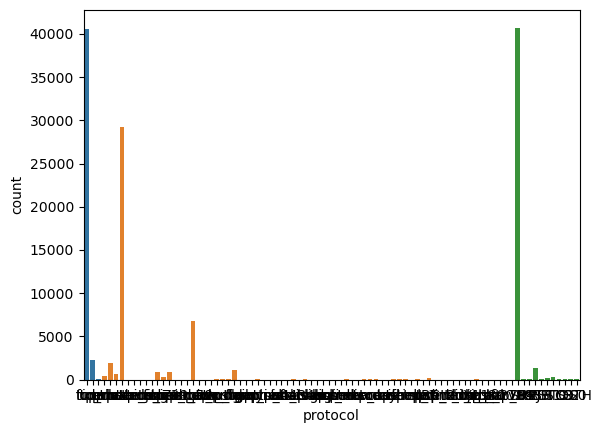

In [14]:
import seaborn as sns

sns.countplot(x='protocol', data=train_df)
sns.countplot(x='scheme', data=train_df)
sns.countplot(x='status', data=train_df)


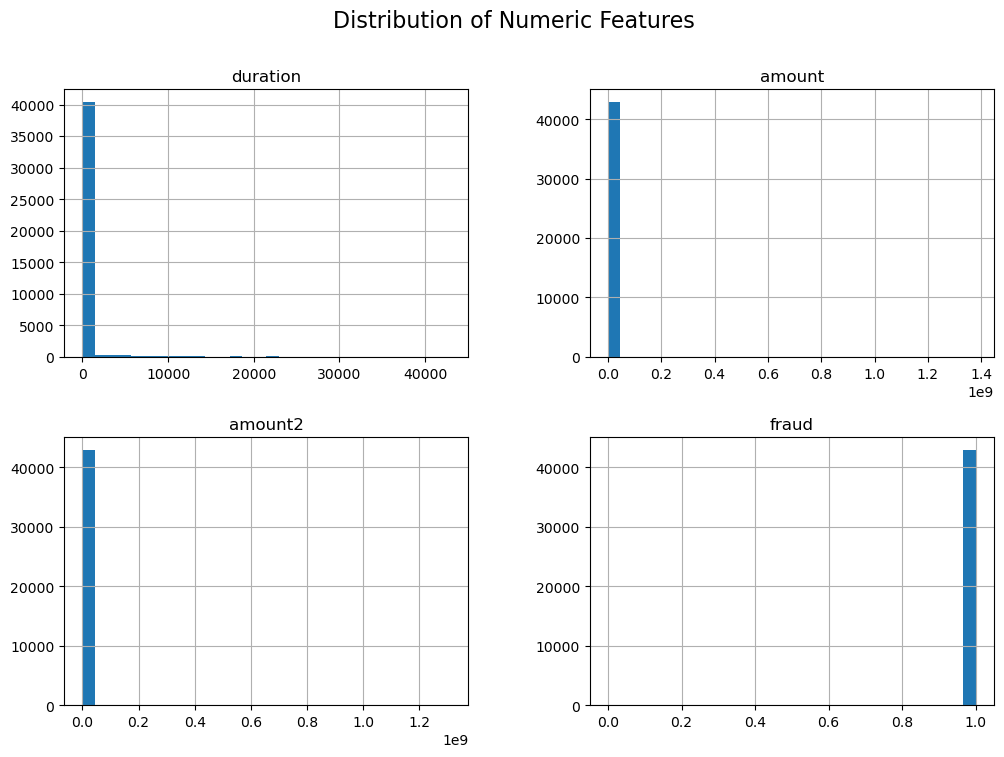

In [17]:
import matplotlib.pyplot as plt

numeric_cols = train_df.select_dtypes(include=['int64','float64']).columns
train_df[numeric_cols].hist(bins=30, figsize=(12,8))
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()


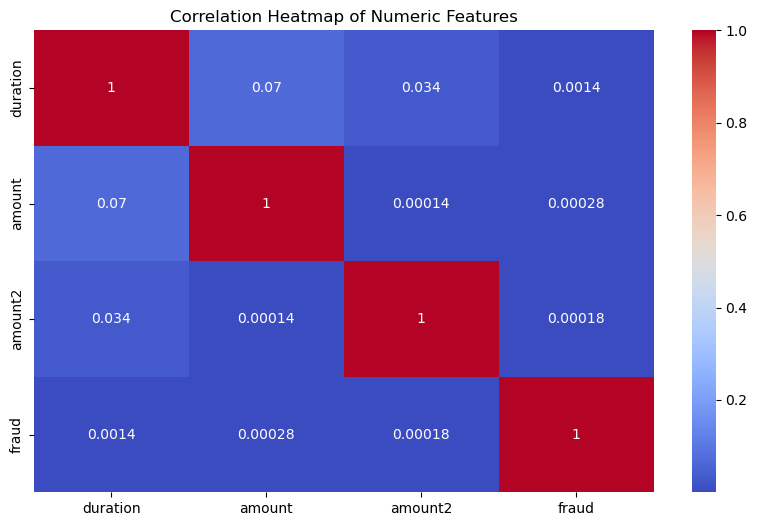

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns automatically
numeric_cols = train_df.select_dtypes(include=['int64','float64']).columns

# Compute correlation matrix
corr = train_df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()
